# Esame Finale — Machine Learning Supervisionato

---

## Brief Aziendale

Sei un Data Scientist del team di **BIP AI LAB**. La nostra azienda collabora costantemente con diversi clienti operanti in svariati settori, aiutandoli a estrarre valore dai loro dati storici per supportare le decisioni strategiche del management.

A seconda del cliente a cui verrai assegnato, avrai a disposizione uno specifico dataset su cui sviluppare la tua soluzione predittiva. Tieni a mente che ogni dataset pone sfide differenti e richiede considerazioni e approcci mirati, soprattutto nelle fasi di analisi e preparazione dei dati.

## Istruzioni per lo Svolgimento

Il tuo compito principale sarà quello di scegliere il modello di machine learning supervisionato più appropriato per il tuo caso di studio, selezionandolo tra quelli affrontati durante il corso: la **Linear Regression** o la **Logistic Regression**.

Dovrai gestire l'intera pipeline per estrarre valore dai dati che ti sono stati assegnati, addestrare il modello secondo le tecniche studiate e valutarne l'output nel contesto specifico del problema. Poni particolare enfasi sulla comprensione del contesto dei dati: sarà fondamentale per compiere delle scelte analitiche mirate, che dovrai poi giustificare durante la presentazione finale.

Buon lavoro.

In [16]:
# Implementa qui la tua soluzione
# import e setup delle librerie necessarie allo svolgimento
import numpy as np                 # array e calcolo numerico
import pandas as pd                # tabelle (DataFrame) e lettura/gestione dati tabellari
import matplotlib.pyplot as plt    # creazione di grafici

# Strumenti di scikit-learn 
from sklearn.model_selection import train_test_split, GridSearchCV   # split dei dati e ricerca iperparametri
from sklearn.preprocessing import StandardScaler, PolynomialFeatures  # standardizzazione e feature polinomiali
from sklearn.linear_model import LinearRegression, Ridge, Lasso       # i tre modelli lineari che confrontiamo
from sklearn.pipeline import Pipeline                                  # per concatenare piu passaggi in un unico oggetto
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.impute import SimpleImputer               # metriche di valutazione

plt.rcParams["figure.figsize"] = (7, 4.5)
RANDOM_STATE = 42

# Step 1: CARICAMENTO E LETTURA DATABASE

In [3]:
# Caricamento del dataset 
DATASET = "boston_housing.csv"

# Carichiamo il file CSV in un DataFrame pandas: una tabella con una riga per immobile
df = pd.read_csv(DATASET)

In [4]:
# Controllo rapido: quanti immobili abbiamo caricato?
print("Numero di immobili nel dataset:", len(df))

# Mostriamo le prime 5 righe per un controllo visivo della struttura dei dati
df.head()

Numero di immobili nel dataset: 506


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,NaN,36.2


In [5]:
df.describe().round(2)

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
count,486.00,486.00,486.00,486.00,506.00,506.00,486.00,506.00,506.00,506.00,506.00,506.00,486.00,506.00
mean,3.61,11.21,11.08,0.07,0.55,6.28,68.52,3.80,9.55,408.24,18.46,356.67,12.72,22.53
std,8.72,23.39,6.84,0.26,0.12,0.70,28.00,2.11,8.71,168.54,2.16,91.29,7.16,9.20
min,0.01,0.00,0.46,0.00,0.38,3.56,2.90,1.13,1.00,187.00,12.60,0.32,1.73,5.00
25%,0.08,0.00,5.19,0.00,0.45,5.89,45.18,2.10,4.00,279.00,17.40,375.38,7.12,17.02
50%,0.25,0.00,9.69,0.00,0.54,6.21,76.80,3.21,5.00,330.00,19.05,391.44,11.43,21.20
75%,3.56,12.50,18.10,0.00,0.62,6.62,93.98,5.19,24.00,666.00,20.20,396.22,16.96,25.00
max,88.98,100.00,27.74,1.00,0.87,8.78,100.00,12.13,24.00,711.00,22.00,396.90,37.97,50.00


In [6]:
# Controllo la presenza di dati mancanti
# isna() marca ogni cella con True/False (mancante o no), sum() conta i True per colonna.
df.isna().sum()

CRIM       20
ZN         20
INDUS      20
CHAS       20
NOX         0
RM          0
AGE        20
DIS         0
RAD         0
TAX         0
PTRATIO     0
B           0
LSTAT      20
MEDV        0
dtype: int64

# Step 2: GESTIONE DEI VALORI MANCANTI

Prima di addestrare un modello di Machine Learning è necessario verificare la presenza di valori mancanti (NaN).

Nel nostro dataset alcune feature presentano 20 valori mancanti. Poiché rappresentano circa il 4% del dataset, invece di eliminare le righe scegliamo di sostituirli (imputazione), così da non perdere informazioni utili.

Per le variabili numeriche utilizziamo la **media**, mentre per la variabile categorica **CHAS** utilizziamo il valore più frequente (mode), poiché è una variabile binaria (0/1).

In [9]:
# Copia del dataset
df_clean = df.copy()

# Variabili numeriche con valori mancanti
num_cols = ["CRIM", "ZN", "INDUS", "AGE", "LSTAT"]

# Variabile categorica/binaria
cat_cols = ["CHAS"]

# Imputazione con la media
mean_imputer = SimpleImputer(strategy="mean")
df_clean[num_cols] = mean_imputer.fit_transform(df_clean[num_cols])

# Imputazione con il valore più frequente
mode_imputer = SimpleImputer(strategy="most_frequent")
df_clean[cat_cols] = mode_imputer.fit_transform(df_clean[cat_cols])

print("Valori mancanti dopo l'imputazione:")
print(df_clean.isnull().sum())

Valori mancanti dopo l'imputazione:
CRIM       0
ZN         0
INDUS      0
CHAS       0
NOX        0
RM         0
AGE        0
DIS        0
RAD        0
TAX        0
PTRATIO    0
B          0
LSTAT      0
MEDV       0
dtype: int64


# Step 3 — Separiamo feature (X) e target (y)

`df_clean` (il nostro dataset) contiene sia le feature sia il target nella stessa
tabella: separiamo le due parti per poterli utilizzare per addestrare un modello

In [ ]:
X = df_clean.drop(columns=["MEDV"]).values   # .values converte da DataFrame ad array numpy, formato richiesto da scikit-learn

# selezioniamo solo la colonna del target
y = df_clean["MEDV"].values                    

print("Forma di X (osservazioni, feature):", X.shape) #shape converte il dato in una tupla e quindi immutabile 
print("Forma di y (target):", y.shape)

Forma di X (osservazioni, feature): (506, 13)
Forma di y (target): (506,)


## Analisi del target: distribuzione di MEDV

Prima di procedere, osserviamo come è distribuito il valore mediano delle
abitazioni (MEDV). Questo ci aiuta a individuare eventuali valori estremi
o anomalie nella variabile che il modello dovrà imparare a prevedere.

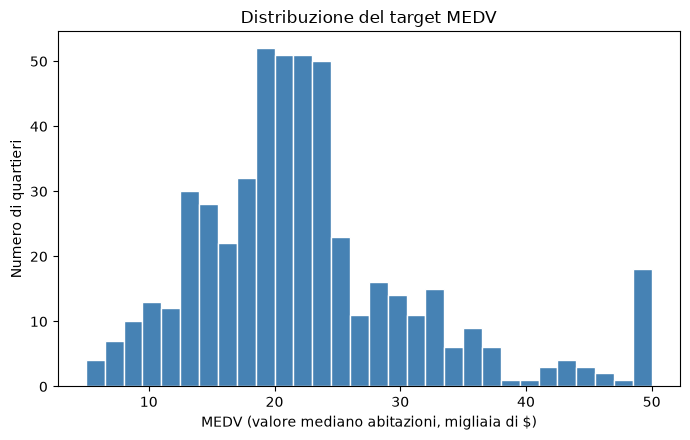

In [27]:
plt.figure()
plt.hist(df_clean["MEDV"], bins=30, color="steelblue", edgecolor="white")
plt.xlabel("MEDV (valore mediano abitazioni, migliaia di $)")
plt.ylabel("Numero di quartieri")
plt.title("Distribuzione del target MEDV")
plt.tight_layout()
plt.show()

## Matrice di correlazione tra le feature

Calcoliamo la correlazione tra tutte le variabili numeriche, incluso il
target MEDV. Questo ci permette di individuare:
- quali feature sono più legate al prezzo delle abitazioni;
- eventuali coppie di feature molto correlate tra loro (multicollinearità),
  che giustifica l'uso di modelli regolarizzati come Ridge.

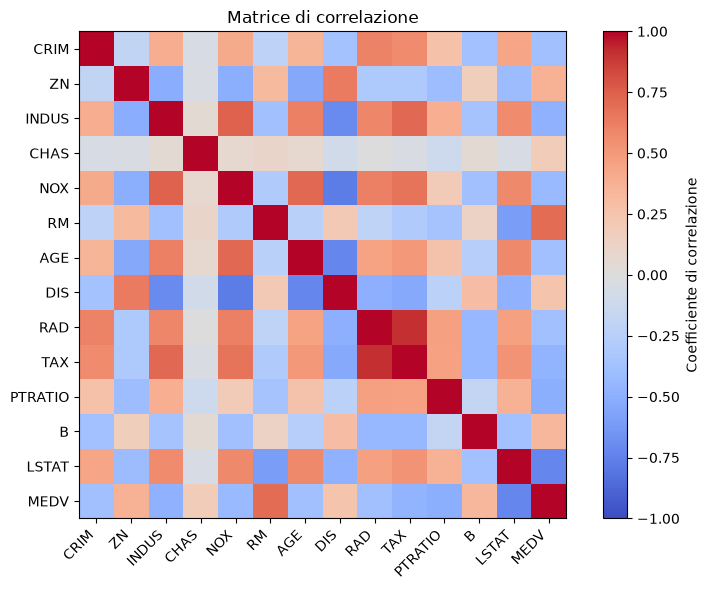

MEDV       1.000000
RM         0.695360
ZN         0.365943
B          0.333461
DIS        0.249929
CHAS       0.183844
CRIM      -0.379695
AGE       -0.380223
RAD       -0.381626
NOX       -0.427321
TAX       -0.468536
INDUS     -0.478657
PTRATIO   -0.507787
LSTAT     -0.721975
Name: MEDV, dtype: float64


In [29]:
corr = df_clean.corr()

plt.figure(figsize=(8, 6))
im = plt.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar(im, label="Coefficiente di correlazione")
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45, ha="right")
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Matrice di correlazione")
plt.tight_layout()
plt.show()

# Correlazione delle sole feature con il target, ordinata: utile per capire
# subito quali variabili "pesano" di più su MEDV
print(corr["MEDV"].sort_values(ascending=False))

## Relazione tra le feature più correlate e il target

Visualizziamo la relazione tra MEDV e le due feature più correlate emerse
dalla matrice di correlazione: **RM** (numero medio di stanze, correlazione
positiva) e **LSTAT** (percentuale di popolazione a status socio-economico
basso, correlazione negativa). Una relazione visivamente lineare conferma
che un modello come la Regressione Lineare è una scelta ragionevole per
questo problema.

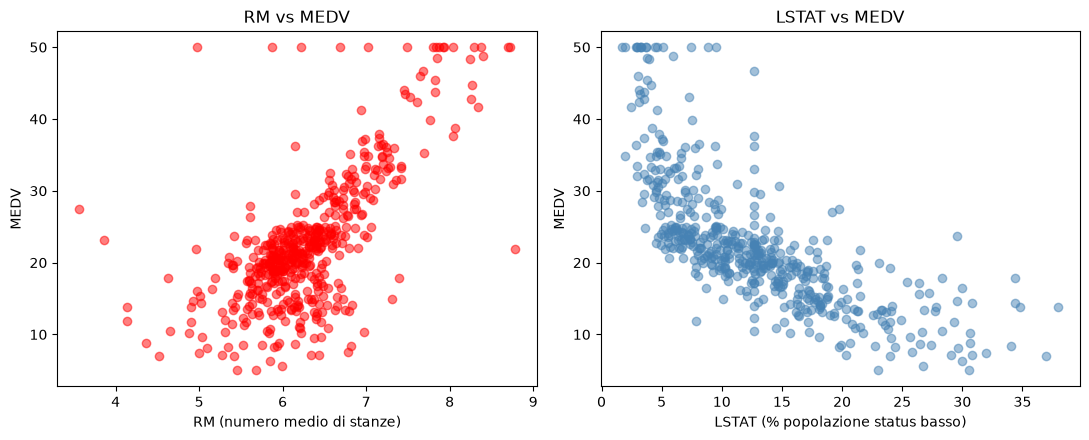

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

axes[0].scatter(df_clean["RM"], df_clean["MEDV"], alpha=0.5, color="red")
axes[0].set_xlabel("RM (numero medio di stanze)")
axes[0].set_ylabel("MEDV")
axes[0].set_title("RM vs MEDV")

axes[1].scatter(df_clean["LSTAT"], df_clean["MEDV"], alpha=0.5, color="steelblue")
axes[1].set_xlabel("LSTAT (% popolazione status basso)")
axes[1].set_ylabel("MEDV")
axes[1].set_title("LSTAT vs MEDV")

plt.tight_layout()
plt.show()

# Step 4 — Split 80/20 (train/test)

`train_test_split` divide casualmente le righe: l'80% in training (per
imparare i pesi), il 20% in test (mai visto durante l'addestramento,
usato solo per la valutazione finale). `random_state` fissa il seme
casuale dello split, cosi il risultato e' riproducibile.

In [38]:
# test_size=0.20 lascia il 20% delle osservazioni fuori dall'addestramento
# random_state=42 fissa il seme casuale: rieseguendo lo script otteniamo
# sempre la stessa divisione tra train e test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42 #quindi utilizzerà sempre stesse righe sia per il train e sia per la val
)

print("Osservazioni di training:", X_train.shape[0])   
print("Osservazioni di test:", X_test.shape[0])          

Osservazioni di training: 404
Osservazioni di test: 102


# Step 5 — Standardizzazione delle feature

Le feature del dataset hanno scale diverse (ad esempio TAX assume valori molto più grandi di RM). Per evitare che le variabili con valori numericamente più elevati influenzino maggiormente il modello, utilizziamo **StandardScaler**.

Lo scaler viene addestrato solo sul training set (`fit_transform`) e successivamente applicato al test set (`transform`) per evitare il data leakage.

In [14]:
# Creazione dello scaler
scaler = StandardScaler()

# Standardizzazione del training set
X_train_scaled = scaler.fit_transform(X_train)

# Standardizzazione del test set
X_test_scaled = scaler.transform(X_test)

# Verifica
print("Media:", X_train_scaled.mean(axis=0).round(3))
print("Deviazione standard:", X_train_scaled.std(axis=0).round(3))

Media: [-0. -0.  0.  0. -0. -0. -0. -0. -0. -0.  0.  0. -0.]
Deviazione standard: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


# Step 7 — Addestramento della Regressione Lineare

La Regressione Lineare viene utilizzata come modello di riferimento (baseline).

L'obiettivo è stimare il valore delle abitazioni (MEDV) a partire dalle feature del dataset.

Dopo l'addestramento, il modello viene utilizzato per effettuare le previsioni sul test set.

In [15]:
# Creazione del modello
lin_reg = LinearRegression()

# Addestramento
lin_reg.fit(X_train_scaled, y_train)

# Predizioni
y_pred_lr = lin_reg.predict(X_test_scaled)

# Step 8 — Valutazione della Regressione Lineare

Per valutare il modello utilizziamo tre metriche:

- **MAE (Mean Absolute Error):** errore medio assoluto.
- **RMSE (Root Mean Squared Error):** penalizza maggiormente gli errori elevati.
- **R² (Coefficiente di determinazione):** indica quanta variabilità della variabile target viene spiegata dal modello.

In [17]:
mae = mean_absolute_error(y_test, y_pred_lr)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2 = r2_score(y_test, y_pred_lr)

print(f"MAE : {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²  : {r2:.3f}")

MAE : 3.16
RMSE: 5.00
R²  : 0.658


# Step 9 — Ridge Regression

La Ridge Regression è una variante della Regressione Lineare che introduce una penalizzazione L2 sui coefficienti.

Lo scopo è ridurre l'overfitting e rendere il modello più stabile, mantenendo tutte le feature nel modello.

In [18]:
ridge = Ridge(alpha=1.0)

ridge.fit(X_train_scaled, y_train)

y_pred_ridge = ridge.predict(X_test_scaled)

mae_ridge = mean_absolute_error(y_test, y_pred_ridge)
rmse_ridge = np.sqrt(mean_squared_error(y_test, y_pred_ridge))
r2_ridge = r2_score(y_test, y_pred_ridge)

print(f"MAE : {mae_ridge:.2f}")
print(f"RMSE: {rmse_ridge:.2f}")
print(f"R²  : {r2_ridge:.3f}")

MAE : 3.15
RMSE: 5.00
R²  : 0.658


# Step 10 — Ridge Regression con Cross-Validation

Il valore di `alpha=1.0` usato nello Step 9 è stato scelto arbitrariamente.
Per giustificare la scelta del parametro di regolarizzazione, usiamo
`GridSearchCV`: proviamo diversi valori di alpha e, tramite 5-fold
cross-validation sul training set, selezioniamo quello che generalizza
meglio (valutato con R²).

Il test set non viene mai usato in questa fase, per evitare data leakage:
lo useremo solo alla fine, per la valutazione conclusiva del modello scelto.

In [21]:
# Griglia di valori di alpha da provare
griglia_alpha = {"alpha": [0.01, 0.1, 1, 10, 30, 100]}

# GridSearchCV valuta ogni alpha con 5-fold cross-validation, usando R2 come metrica
ricerca_ridge = GridSearchCV(
    Ridge(), griglia_alpha, cv=5, scoring="r2", n_jobs=-1
)

# Addestriamo la ricerca sul training set standardizzato
ricerca_ridge.fit(X_train_scaled, y_train)

print("Miglior alpha trovato per Ridge:", ricerca_ridge.best_params_["alpha"])
print("R2 medio in cross-validation:", round(ricerca_ridge.best_score_, 3))

Miglior alpha trovato per Ridge: 10
R2 medio in cross-validation: 0.714


# Step 11 — Valutazione del Ridge ottimizzato sul test set

Usiamo il modello con il miglior alpha trovato dalla cross-validation
per fare previsioni sul test set, e calcoliamo le stesse metriche
usate per gli altri modelli.

In [22]:
# ricerca_ridge.predict() usa automaticamente il miglior modello trovato dalla CV
y_pred_ridge_cv = ricerca_ridge.predict(X_test_scaled)

mae_ridge_cv = mean_absolute_error(y_test, y_pred_ridge_cv)
rmse_ridge_cv = np.sqrt(mean_squared_error(y_test, y_pred_ridge_cv))
r2_ridge_cv = r2_score(y_test, y_pred_ridge_cv)

print(f"MAE : {mae_ridge_cv:.2f}")
print(f"RMSE: {rmse_ridge_cv:.2f}")
print(f"R²  : {r2_ridge_cv:.3f}")

MAE : 3.15
RMSE: 5.01
R²  : 0.658


# Step 12 — Tabella riassuntiva dei risultati

Raccogliamo le metriche dei tre modelli — Linear Regression, Ridge con
alpha fisso e Ridge ottimizzato tramite cross-validation — in un'unica
tabella, per confrontarle in modo diretto prima della valutazione finale.

In [23]:
risultati = [
    ("Linear Regression", r2, rmse, mae),
    ("Ridge (alpha=1.0)", r2_ridge, rmse_ridge, mae_ridge),
    ("Ridge (CV, alpha ottimo)", r2_ridge_cv, rmse_ridge_cv, mae_ridge_cv),
]

tabella = pd.DataFrame(risultati, columns=["Modello", "R2", "RMSE", "MAE"]).round(3)
tabella

,Modello,R2,RMSE,MAE
0,Linear Regression,0.658,5.004,3.156
1,Ridge (alpha=1.0),0.658,5.005,3.155
2,"Ridge (CV, alpha ottimo)",0.658,5.009,3.146


## Predetto vs Reale — modello migliore

Confrontiamo i valori previsti dal modello con il miglior R² (Ridge
ottimizzato in cross-validation) con i valori reali di MEDV sul test set.
Se il modello prevede bene, i punti si dispongono vicino alla diagonale
a 45°.

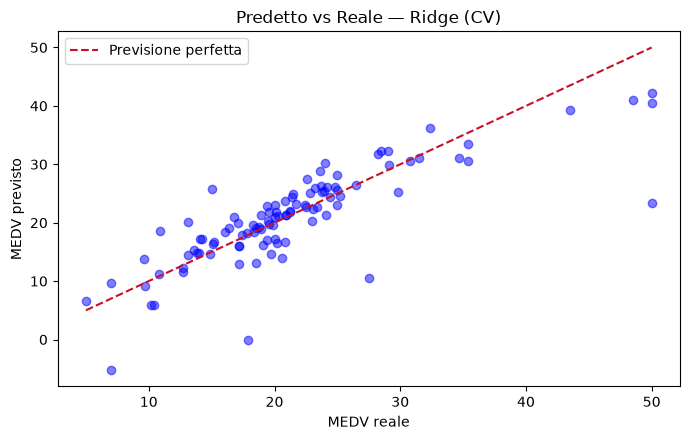

In [34]:
plt.figure()
plt.scatter(y_test, y_pred_ridge_cv, alpha=0.5, color="blue")

# Diagonale di riferimento: previsione perfetta
lim = [y_test.min(), y_test.max()]
plt.plot(lim, lim, color="#C8102E", linestyle="--", label="Previsione perfetta")

plt.xlabel("MEDV reale")
plt.ylabel("MEDV previsto")
plt.title("Predetto vs Reale — Ridge (CV)")
plt.legend()
plt.tight_layout()
plt.show()

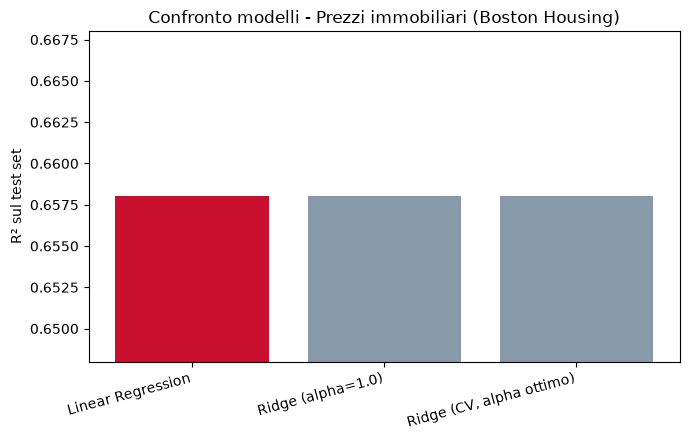

In [37]:
plt.figure()

nomi = tabella["Modello"]
valori_r2 = tabella["R2"]

# idxmax() restituisce l'indice della prima riga con il valore massimo,
# invece di confrontare i valori (che dopo l'arrotondamento possono coincidere)
indice_migliore = valori_r2.idxmax()
colori = ["#C8102E" if i == indice_migliore else "#8899aa" for i in range(len(valori_r2))]

plt.bar(nomi, valori_r2, color=colori)
plt.ylabel("R² sul test set")
plt.title("Confronto modelli - Prezzi immobiliari (Boston Housing)")
plt.xticks(rotation=15, ha="right")

margine = (valori_r2.max() - valori_r2.min()) * 0.5 + 0.01
plt.ylim(valori_r2.min() - margine, valori_r2.max() + margine)

plt.tight_layout()
plt.show()

# Conclusioni

Sul test set, Linear Regression, Ridge (alpha=1.0) e Ridge ottimizzato in
cross-validation ottengono prestazioni pressoché identiche: R² = 0.658 per
tutti e tre, RMSE intorno a 5.00, MAE intorno a 3.15. La cross-validation ha
individuato alpha=10 come valore ottimale (R² medio in CV = 0.714, più alto
del punteggio sul singolo test set, come atteso essendo una media su più
fold), ma questo non si è tradotto in un guadagno concreto sul test set.

Questo risultato è di per sé un'informazione utile: con sole 13 feature e
404 osservazioni di training, il modello OLS di base non soffre di
overfitting significativo, quindi la regolarizzazione non ha margine per
migliorare le prestazioni. L'analisi esplorativa conferma la scelta del
modello lineare: RM e LSTAT — le due feature più correlate con MEDV — mostrano
una relazione visivamente lineare con il target, e il grafico Predetto vs
Reale mostra che il modello segue bene la diagonale, con qualche scostamento
maggiore sui prezzi più alti.

Dato che le prestazioni sono equivalenti, la scelta finale ricade sul modello
più semplice e interpretabile: la **Regressione Lineare**. La versione Ridge
ottimizzata resta comunque un'alternativa solida e giustificata da preferire
in un contesto con più feature o meno dati, dove il rischio di overfitting
sarebbe maggiore.